# Error analysis

Every Spider-dev prediction of the FULL model that is not both an exact match and an execution match is labelled with the taxonomy in `ratsql/analysis/errors.py` (primary label = first in priority order). Nothing is cherry-picked: samples below are drawn uniformly at random per category with a fixed seed.

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
pd.set_option("display.max_colwidth", 200)

In [2]:
err = pd.read_csv(ROOT / "results/tables/error_analysis_full.csv")
print(len(err), "failures")
err.primary_error.value_counts()

432 failures


primary_error
schema_linking_error        107
wrong_column                 85
nested_query_error           56
wrong_table                  52
wrong_join                   43
aggregation_error            22
where_error                  21
wrong_value                  19
order_by_error               15
group_by_error               11
semantic_reasoning_error      1
Name: count, dtype: int64

### Primary error category (Spider dev failures, our measurements)

| Category | full | no_grammar | no_linking | simple | vanilla |
|---|---|---|---|---|---|
| grammar_error | 0 | 754 | 2 | 0 | 0 |
| nested_query_error | 56 | 9 | 86 | 94 | 78 |
| schema_linking_error | 107 | 22 | 229 | 680 | 366 |
| wrong_table | 52 | 12 | 68 | 108 | 129 |
| wrong_join | 43 | 4 | 28 | 30 | 69 |
| wrong_column | 85 | 8 | 91 | 32 | 63 |
| aggregation_error | 22 | 1 | 9 | 1 | 6 |
| where_error | 21 | 7 | 22 | 2 | 12 |
| group_by_error | 11 | 0 | 3 | 2 | 3 |
| order_by_error | 15 | 1 | 10 | 0 | 9 |
| wrong_value | 19 | 11 | 17 | 0 | 7 |
| semantic_reasoning_error | 1 | 0 | 0 | 0 | 0 |
| **total failures** | 432 | 829 | 565 | 949 | 742 |


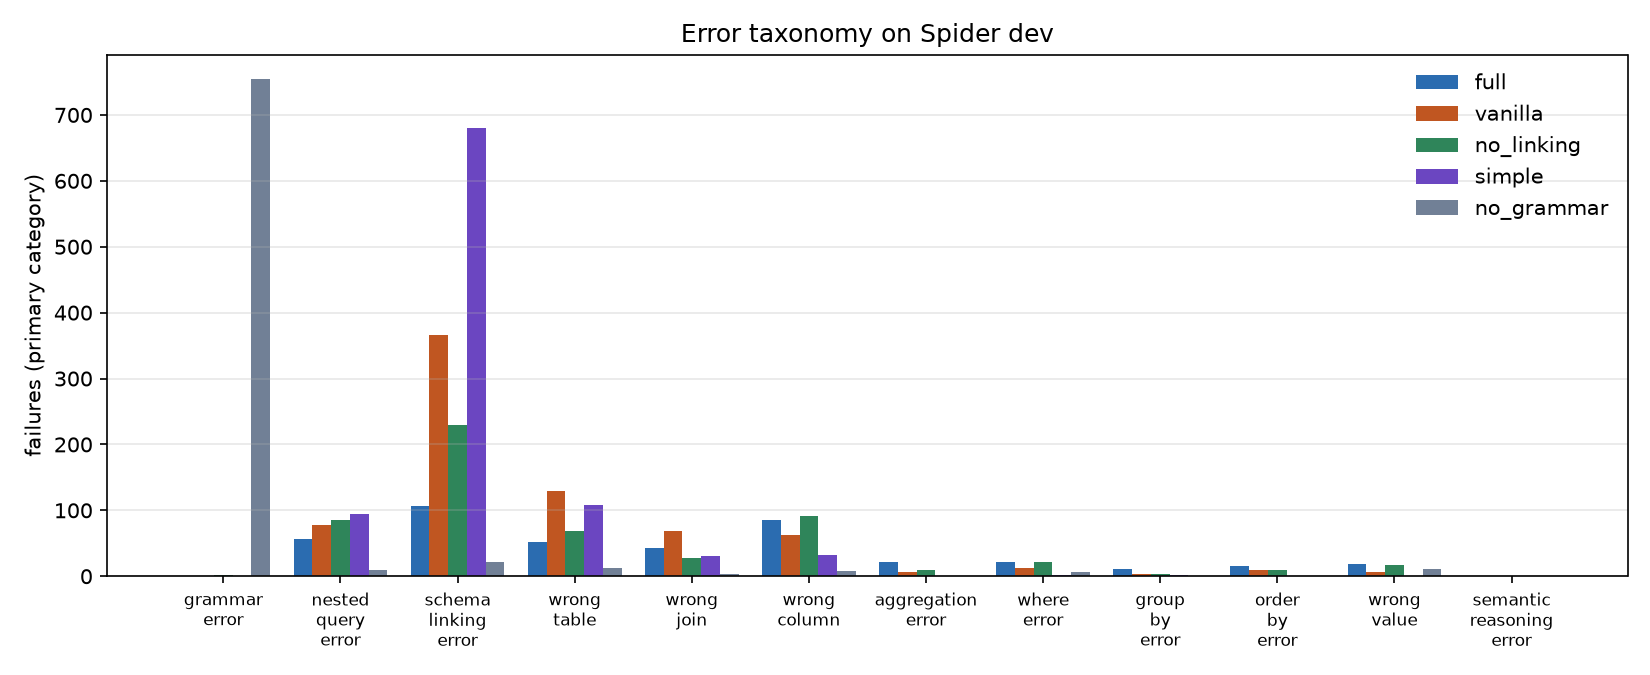

In [3]:
display(Markdown((ROOT / "results/tables/error_distribution.md").read_text(encoding="utf-8")))
display(Image(filename=str(ROOT / "results/plots/error_distribution.png")))

In [4]:
pd.crosstab(err.primary_error, err.hardness).reindex(columns=["easy", "medium", "hard", "extra"])

hardness,easy,medium,hard,extra
primary_error,,,,
aggregation_error,3,18,1,0
group_by_error,0,7,1,3
nested_query_error,5,5,22,24
order_by_error,4,9,2,0
schema_linking_error,12,52,21,22
semantic_reasoning_error,0,0,0,1
where_error,4,10,6,1
wrong_column,12,45,12,16
wrong_join,0,12,11,20


In [5]:
labels = err.error_labels.str.split("|").explode()
labels.value_counts().rename("any-label count")

error_labels
wrong_column                268
where_error                 158
wrong_table                 133
schema_linking_error        128
wrong_join                   90
group_by_error               85
order_by_error               68
nested_query_error           56
wrong_value                  33
aggregation_error            23
semantic_reasoning_error      1
Name: any-label count, dtype: int64

## Random samples per category

In [6]:
for cat, g in err.groupby("primary_error"):
    print("=" * 100); print(cat, f"({len(g)})")
    for _, r in g.sample(min(3, len(g)), random_state=0).iterrows():
        print("Q   :", r.question); print("GOLD:", r.gold_sql); print("PRED:", r.pred_sql); print("WHY :", r.analysis); print()

aggregation_error (22)
Q   : Show me the cost of the most recently performed treatment.
GOLD: SELECT cost_of_treatment FROM Treatments ORDER BY date_of_treatment DESC LIMIT 1
PRED: SELECT max(cost_of_treatment) FROM Treatments ORDER BY date_of_treatment DESC LIMIT 1
WHY : aggregation functions differ

Q   : Whose permanent address is different from his or her current address? List his or her first name.
GOLD: SELECT first_name FROM Students WHERE current_address_id != permanent_address_id
PRED: SELECT first_name, current_address_id FROM Students
WHY : aggregation functions differ; WHERE conditions differ (operators / conjunctions / count)

Q   : What is the average GNP and total population in all nations whose government is US territory?
GOLD: SELECT avg(GNP) ,  sum(population) FROM country WHERE GovernmentForm  =  "US Territory"
PRED: SELECT avg(GNP), avg(Population) FROM country WHERE GovernmentForm = 'US Territory'
WHY : aggregation functions differ

group_by_error (11)
Q   : Find a

## Accuracy by query complexity

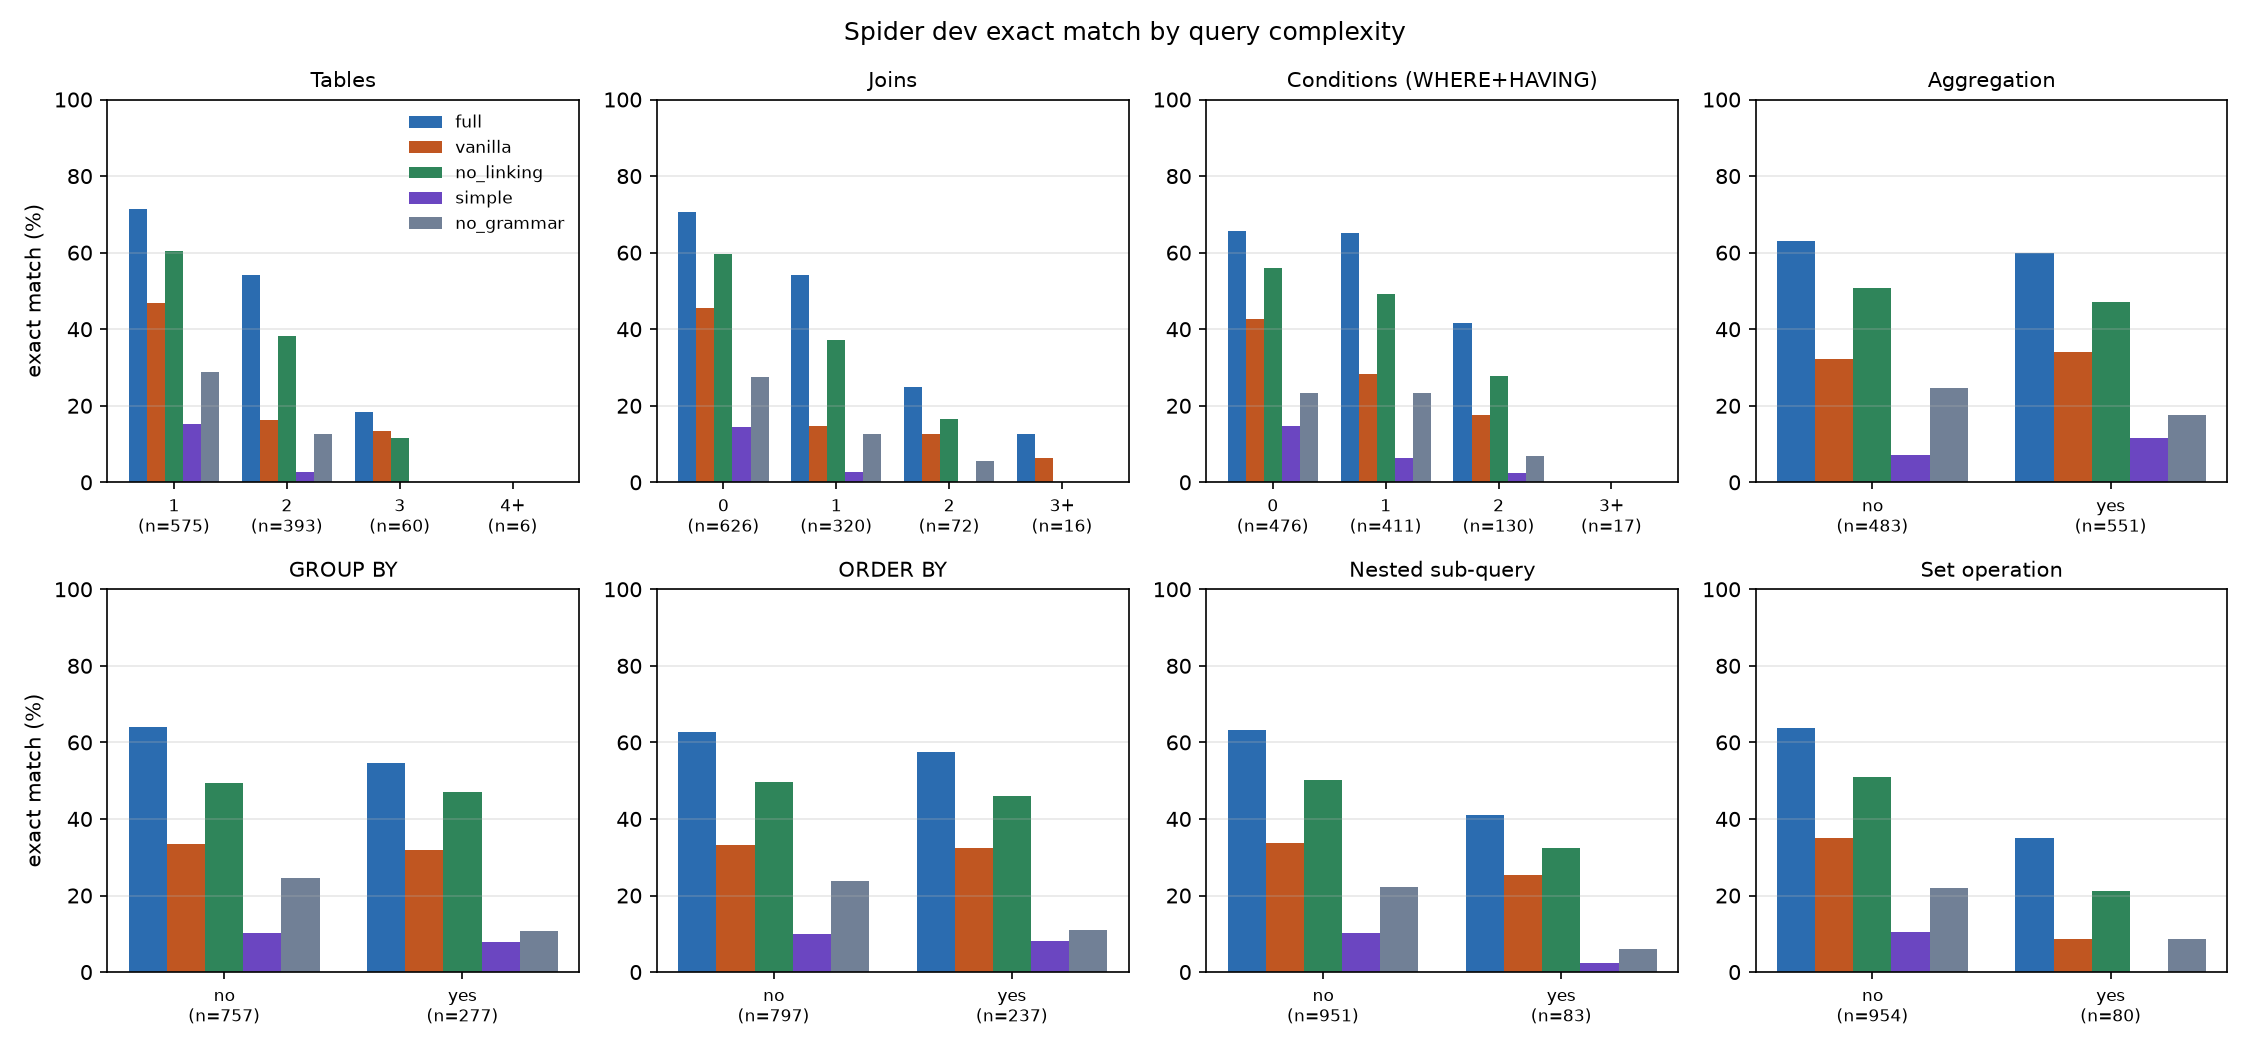

model                              full  no_grammar  no_linking  simple  \
feature                   bucket                                          
Aggregation               no      0.631       0.246       0.507   0.072   
                          yes     0.599       0.176       0.470   0.116   
Conditions (WHERE+HAVING) 0       0.658       0.233       0.559   0.147   
                          1       0.652       0.234       0.491   0.063   
                          2       0.415       0.069       0.277   0.023   
                          3+      0.000       0.000       0.000   0.000   
GROUP BY                  no      0.639       0.246       0.494   0.102   
                          yes     0.545       0.108       0.469   0.079   
Joins                     0       0.706       0.275       0.596   0.144   
                          1       0.541       0.125       0.372   0.028   
                          2       0.250       0.056       0.167   0.000   
                          3+      0.125       0.000       0.000   0.000   
Nested sub-query          no      0.632       0.222       0.502   0.102   
                          yes     0.410       0.060       0.325   0.024   
ORDER BY                  no      0.626       0.238       0.496   0.100   
                          yes     0.574       0.110       0.460   0.080   
Set operation             no      0.636       0.219       0.510   0.104   
                          yes     0.350       0.088       0.212   0.000   
Tables                    1       0.715       0.289       0.603   0.153   
                          2       0.542       0.127       0.382   0.028   
                          3       0.183       0.000       0.117   0.000   
                          4+      0.000       0.000       0.000   0.000   

model                             vanilla  
feature                   bucket           
Aggregation               no        0.321  
                          yes       0.339  
Conditions (WHERE+HAVING) 0         0.426  
                          1         0.282  
                          2         0.177  
                          3+        0.000  
GROUP BY                  no        0.336  
                          yes       0.318  
Joins                     0         0.455  
                          1         0.147  
                          2         0.125  
                          3+        0.062  
Nested sub-query          no        0.338  
                          yes       0.253  
ORDER BY                  no        0.332  
                          yes       0.325  
Set operation             no        0.351  
                          yes       0.088  
Tables                    1         0.470  
                          2         0.163  
                          3         0.133  
                          4+        0.000

In [7]:
display(Image(filename=str(ROOT / "results/plots/complexity_em.png")))
pd.read_csv(ROOT / "results/tables/complexity_results.csv").pivot_table(index=["feature", "bucket"], columns="model", values="exact_match").round(3)